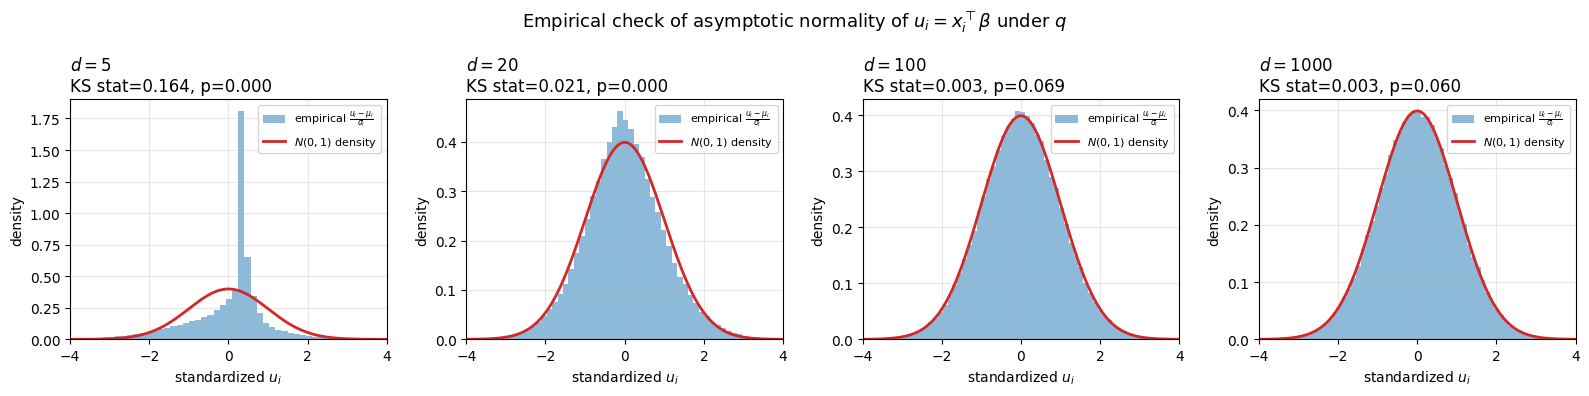

     d |   skewness |  excess kurtosis |  KS stat | KS p-value
     5 |    -0.7073 |           1.2663 |   0.0964 |     0.0000
    20 |    -0.5135 |           0.7843 |   0.0431 |     0.0000
   100 |    -0.0202 |           0.1340 |   0.0034 |     0.0216
  1000 |     0.0000 |           0.0274 |   0.0019 |     0.4863


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ============================================================
# Simulation: check asymptotic normality of u_i = x_i^T beta
# under the variational spike-and-slab distribution q(beta, z),
# as d -> infinity (Lemma on CLT for spike-and-slab).
# ============================================================

rng = np.random.default_rng(42)

# ---------- variational / prior-like parameters ----------
pi0 = 0.3          # gamma_j = P_q(z_j = 1), fixed, independent of d
m_val = 0.5        # variational mean m_j (same for all j, for simplicity)
rho_val = 1.0      # variational variance rho_j (same for all j)

# design point x_i: entries bounded, e.g. i.i.d. from Uniform(-1,1)
def sample_design(d, rng):
    return rng.uniform(-1, 1, size=d)

def sample_design_correlated(d, rng, block_size=10, rho=0.9):
    """
    Sample a single design vector x_i in R^d with a block-correlation structure:
    entries are partitioned into contiguous blocks of size `block_size`, and
    within each block the entries are jointly Gaussian with correlation `rho`
    (compound-symmetry / equicorrelated structure). Different blocks are
    independent of each other. The last block may be smaller than block_size
    if d is not a multiple of block_size.

    Marginally, each entry has mean 0 and variance 1.

    Parameters
    ----------
    d : int
        Dimension of the design vector.
    rng : np.random.Generator
        Random number generator.
    block_size : int
        Size of each correlated block (k).
    rho : float
        Within-block correlation, must satisfy -1/(block_size-1) < rho < 1
        for the covariance matrix to be positive semi-definite.

    Returns
    -------
    x_i : np.ndarray of shape (d,)
    """
    x_i = np.empty(d)
    start = 0
    while start < d:
        k = min(block_size, d - start)
        # Equicorrelated covariance: Sigma = (1-rho) * I_k + rho * ones(k,k)
        Sigma = (1 - rho) * np.eye(k) + rho * np.ones((k, k))
        block_sample = rng.multivariate_normal(np.zeros(k), Sigma)
        x_i[start:start + k] = block_sample
        start += k
    return x_i

# ---------- exact sampler for u_i^(d) = sum_j x_i^(j) * beta_j ----------
def sample_u(d, n_samples, rng, pi0=pi0, m_val=m_val, rho_val=rho_val):
    x_i = sample_design_correlated(d, rng)

    # sample z_j ~ Bernoulli(pi0) and beta_j | z_j from the mixture,
    # for each of n_samples independent draws of beta (Monte Carlo over q)
    z = rng.binomial(1, pi0, size=(n_samples, d))
    beta_slab = rng.normal(m_val, np.sqrt(rho_val), size=(n_samples, d))
    beta = z * beta_slab  # beta_j = 0 when z_j = 0 (spike), else slab draw

    u = beta @ x_i  # shape (n_samples,)
    return u, x_i

# ---------- theoretical mean/variance from the lemma ----------
def theoretical_mean_var(x_i, pi0=pi0, m_val=m_val, rho_val=rho_val):
    gamma = pi0  # constant gamma_j = pi0 here
    v_j = gamma * (rho_val + m_val**2) - gamma**2 * m_val**2  # Var_q(beta_j)
    mu_i = np.sum(x_i * gamma * m_val)
    sigma2_i = np.sum(x_i**2 * v_j)
    return mu_i, sigma2_i

# ---------- run simulation for increasing d ----------
d_values = [5, 20, 100, 1000]
n_samples = 200_000

fig, axes = plt.subplots(1, len(d_values), figsize=(4 * len(d_values), 4))

for ax, d in zip(axes, d_values):
    u, x_i = sample_u(d, n_samples, rng)
    mu_i, sigma2_i = theoretical_mean_var(x_i)
    sigma_i = np.sqrt(sigma2_i)

    # standardize using theoretical mean/variance
    u_std = (u - mu_i) / sigma_i

    # empirical histogram vs. standard normal density
    ax.hist(u_std, bins=80, density=True, alpha=0.5, color='tab:blue',
             label='empirical $\\frac{u_i-\\mu_i}{\\sigma_i}$')
    grid = np.linspace(-4, 4, 300)
    ax.plot(grid, stats.norm.pdf(grid), color='tab:red', linewidth=2,
             label='$N(0,1)$ density')

    # quantify deviation from normality
    ks_stat, ks_pval = stats.kstest(u_std, 'norm')

    ax.set_title(f'$d={d}$\nKS stat={ks_stat:.3f}, p={ks_pval:.3f}', loc='left')
    ax.set_xlabel(r'standardized $u_i$')
    ax.set_ylabel('density')
    ax.legend(fontsize=8)
    ax.set_xlim(-4, 4)
    ax.grid(alpha=0.3)

fig.suptitle('Empirical check of asymptotic normality of $u_i = x_i^\\top\\beta$ under $q$', fontsize=13)
plt.tight_layout()
plt.savefig('clt_spike_and_slab_check.png', dpi=150)
plt.show()

# ---------- additional numeric diagnostics ----------
print(f"{'d':>6} | {'skewness':>10} | {'excess kurtosis':>16} | {'KS stat':>8} | {'KS p-value':>10}")
for d in d_values:
    u, x_i = sample_u(d, n_samples, rng)
    mu_i, sigma2_i = theoretical_mean_var(x_i)
    u_std = (u - mu_i) / np.sqrt(sigma2_i)
    skew = stats.skew(u_std)
    kurt = stats.kurtosis(u_std)  # excess kurtosis (0 for normal)
    ks_stat, ks_pval = stats.kstest(u_std, 'norm')
    print(f"{d:6d} | {skew:10.4f} | {kurt:16.4f} | {ks_stat:8.4f} | {ks_pval:10.4f}")